In [1]:
import sys
import numpy as np
import torch 
import pandas as pd
# still do preprocessing in scipy
import scipy.sparse as sp
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from importlib import reload
# get UMAP
import umap
import LeafletSC

# Append this directory to sys.path
from LeafletSC.clustering.find_intron_clusters import visualize_local_events
from LeafletSC.beta_binomial_mix.modeling import *
from LeafletSC.beta_binomial_mix.calculate_cellstate_consistency import *
from LeafletSC.clustering.load_cluster_data import *

# import factor model from beta-dirichlet-factor
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-private/src/beta-dirichlet-factor')
import factor_model
reload(factor_model)

import matplotlib.pyplot as plt

from scipy.stats import beta
from sklearn.utils import resample

2.3.0+cu121
12.1
2.3.0+cu121
12.1


In [2]:
# Append this directory to sys.path
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-private/src/clustering/')
import load_cluster_data as llc 

# Append also simulation directory
sys.path.append("/gpfs/commons/home/kisaev/Leaflet-private/src/simulation/")
import simulate_counts as sim 
reload (sim)

<module 'simulate_counts' from '/gpfs/commons/home/kisaev/Leaflet-private/src/simulation/simulate_counts.py'>

In [3]:
torch.manual_seed(42)

# set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

float_type = { 
    "device" : device, 
    "dtype" : torch.float, # save memory
}

cuda


In [4]:
# Define path that contains the model input files and append it (input can be a folder with one .h5 file per cell_type for example or one file)
model_input_file='/gpfs/commons/projects/knowles_singlecell_splicing/CZhang_2018_mouse_dev/male_whole_cortex/LeafletAnalysis/mouse_whole_cortex_dev_leaflet.h5'

# convert data to Leaflet required input formats 
final_data, coo_counts_sparse, coo_cluster_sparse, cell_ids_conversion, junction_ids_conversion = load_cluster_data(
     input_file = model_input_file, max_intron_count=100000, remove_singletons=True, has_genes="yes")

# add cluster information to final_data 
final_data = final_data.merge(junction_ids_conversion, on=["junction_id_index"], how="left")

# generate torch tensors for sparse data representation 
cell_index_tensor, junc_index_tensor, my_data = make_torch_data(final_data, **float_type)

# simplify columns 
simple_data = final_data[["cell_id_index", "Cluster", "junction_id_index", "juncratio", "junc_count", "cluster_count",  "junction_id", "gene_id"]]

print("The number of junctions is: ", len(junction_ids_conversion))
print("The number of intron clusters observed is: ", len(junction_ids_conversion.Cluster.unique()))
print("The number of genes is: ", len(junction_ids_conversion.gene_id.unique()))
print("The number of cells is: ", len(simple_data.cell_id_index.unique()))

Reading in data from folder ...
Finished reading in data from folder ...
Removing singletons ...
Number of junctions before removing singletons:  20857
Number of junctions after removing singletons:  20857
The number of unique cell types in the data is:  9
The number of unique cells in the data is:  18
The number of unique junctions in the data is:  20858
The maximum junction count was initially:  42464
0
The maximum junction count is now:  42464
The number of junctions in the data is:  20858
The number of cells in the data is:  18
The number of cell types in the data is:  9
The number of cells going into training data is:
18
18
The number of junctions is:  20858
The number of intron clusters observed is:  7192
The number of genes is:  5412
The number of cells is:  18


/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/LeafletSC/clustering/load_cluster_data.py:47: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at ../aten/src/ATen/SparseCsrTensorImpl.cpp:53.)
  ycount).to_sparse_csr()


In [5]:
# get indices (maybe don't need this actually)
indices = (final_data.cell_id_index, final_data.junction_id_index)
indices_np = np.stack(indices)
junc_counts = sp.coo_matrix((final_data.junc_count, indices))
cluster_counts = sp.coo_matrix((final_data.cluster_count, indices))

In [6]:
if device == torch.device('cuda'):
    torch.set_default_tensor_type('torch.cuda.FloatTensor')

/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/torch/__init__.py:747: UserWarning: torch.set_default_tensor_type() is deprecated as of PyTorch 2.1, please use torch.set_default_dtype() and torch.set_default_device() as alternatives. (Triggered internally at ../torch/csrc/tensor/python_tensor.cpp:431.)
  _C._set_default_tensor_type(t)


In [7]:
indices = torch.tensor(final_data[['cell_id_index', 'junction_id_index']].to_numpy().T, dtype=torch.long)
values = torch.tensor(final_data['junc_count'].to_numpy(), dtype=torch.float)
# Determine the size of the tensor
num_cells = final_data['cell_id_index'].max() + 1
num_junctions = final_data['junction_id_index'].max() + 1
size = (num_cells, num_junctions)
# Create a sparse tensor
y_tensor = torch.sparse_coo_tensor(indices, values, size)

indices_counts = torch.tensor(final_data[['cell_id_index', 'junction_id_index']].to_numpy().T, dtype=torch.long)
values_counts = torch.tensor(final_data['cluster_count'].to_numpy(), dtype=torch.float)
# Determine the size of the tensor
num_cells_counts = final_data['cell_id_index'].max() + 1
num_junctions_counts = final_data['junction_id_index'].max() + 1
size_counts = (num_cells_counts, num_junctions_counts)
# Create a sparse tensor
total_counts_tensor = torch.sparse_coo_tensor(indices_counts, values_counts, size_counts)

# save full dataset y_tensor and total_counts_tensor 
full_y_tensor = y_tensor
full_total_counts_tensor = total_counts_tensor

# how many zeroes in the data compared to total number of values
perc_nonzero = cluster_counts.nnz / (cluster_counts.shape[0] * cluster_counts.shape[1])
print("The percentage of missing values in the intron counts matrix is: ", 1-perc_nonzero)

The percentage of missing values in the intron counts matrix is:  0.03426609560946503


### For simulating data, let's only keep clusters that have exon skipping event, so cluster with three junctions

In [8]:
# SS are shared between end of J1 and start of J2 and end of J2 and start of J3
junc_info = junction_ids_conversion[["junction_id", "Cluster", "junction_id_index"]].drop_duplicates()

# get number of junctions in each cluster first 
cluster_junc_counts = junc_info.groupby(["Cluster"]).agg({"junction_id": "count"}).reset_index()
clusts_keep = cluster_junc_counts[cluster_junc_counts["junction_id"] == 3 ]
junc_info = junc_info[junc_info["Cluster"].isin(clusts_keep["Cluster"])]

# break up junction_id column in junc_info into chr, start and end 
junc_info["chr"] = junc_info["junction_id"].str.split("_").str[0]
junc_info["start"] = junc_info["junction_id"].str.split("_").str[1]
junc_info["end"] = junc_info["junction_id"].str.split("_").str[2]
print(len(junc_info["Cluster"].unique()))

3317


In [9]:
# run function on all clusters to find simple exon skipping events 
clusters_SS = []

for cluster in tqdm(junc_info["Cluster"].unique()): # this is very slow
    clusters_SS.append(sim.check_SS_cluster(final_data, junc_info, cluster))

# keep only entries in clusters_SS that are not None 
clusters_SS = [x for x in clusters_SS if x is not None]
print(len(clusters_SS))

# get indices of junctions in clusters_SS (original indices before filtering)
junc_ind_keep = junction_ids_conversion[junction_ids_conversion["Cluster"].isin(clusters_SS)]["junction_id_index"]
print(len(junc_ind_keep))
final_data = final_data[final_data.junction_id_index.isin(junc_ind_keep)] #using original junction id index

# filter junction_ids file to only include junctions in clusters_SS
junction_ids_conversion = junction_ids_conversion[junction_ids_conversion["junction_id_index"].isin(junc_ind_keep)]
# reset index of junction_ids_conversion and make a new column new_junction_id_index
junction_ids_conversion = junction_ids_conversion.reset_index(drop=True)
# re-order junction_ids_conversion junction_id_index
junction_ids_conversion = junction_ids_conversion.sort_values(by=['junction_id_index'])
junction_ids_conversion["new_junction_id_index"] = junction_ids_conversion.index
print(junction_ids_conversion.head())

# re-order the remaining junctions and subset the counts matrices
final_data = final_data.merge(junction_ids_conversion, on=["junction_id_index", "Cluster", "junction_id"])

# where is new_junction_id_index coming from here? 
final_data.sort_values(by = ["new_junction_id_index"], inplace = True)
final_data.head()

to_keep = final_data["junction_id_index"].unique()   # use original junction indices to filter out the count matrices 
junc_counts_sub = junc_counts.tocsr()[:,to_keep].tocoo()
cluster_counts_sub = cluster_counts.tocsr()[:,to_keep].tocoo()

100%|██████████| 3317/3317 [00:11<00:00, 286.68it/s]


3317
9951
   junction_id_index            junction_id  Cluster                gene_id  \
0                  0    1_36560920_36563114        3  ENSMUSG00000001138.14   
1                  1    1_36560920_36564246        3  ENSMUSG00000001138.14   
2                  2    1_36563213_36564246        3  ENSMUSG00000001138.14   
3                  3  1_171213306_171213727       19  ENSMUSG00000006411.13   
4                  4  1_171213802_171214148       19  ENSMUSG00000006411.13   

   new_junction_id_index  
0                      0  
1                      1  
2                      2  
3                      3  
4                      4  


In [10]:
# sanity check that counts are saved in correct indices in sparse matrices
ind_random = np.random.randint(0, len(final_data))
print(final_data.iloc[ind_random])
print(junc_counts_sub.toarray()[final_data.iloc[ind_random].cell_id_index, final_data.iloc[ind_random].new_junction_id_index])
print(cluster_counts_sub.toarray()[final_data.iloc[ind_random].cell_id_index, final_data.iloc[ind_random].new_junction_id_index])

cell_id_index                                3
junction_id_index                         1510
junc_count                               199.0
cluster_count                              363
clustminjunc                             164.0
juncratio                             0.548209
cell_id                             SRR1805817
cell_type                                   P0
junction_id                2_30026725_30027132
Cluster                                   4072
gene_id_x                ENSMUSG00000039678.13
gene_id_y                ENSMUSG00000039678.13
new_junction_id_index                      733
Name: 28950, dtype: object
199.0
363


<Axes: xlabel='juncratio', ylabel='Count'>

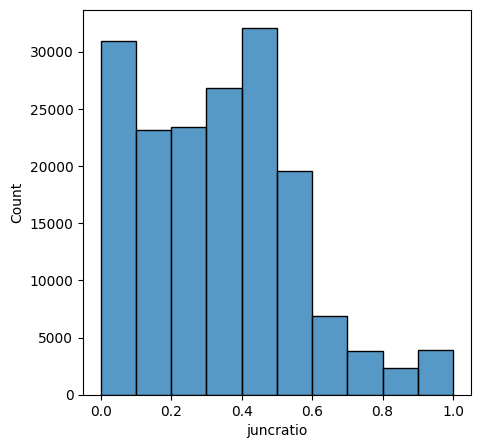

In [11]:
# set figure size to be small
plt.figure(figsize=(5,5))
sns.histplot(final_data.juncratio, bins=10)

### Let's simulate some data!

In [12]:
# update junc_info to only include junctions in clusters_SS
junc_info = junc_info[junc_info["Cluster"].isin(clusters_SS)]
junc_info = junc_info.reset_index(drop=True)
junc_info["new_junction_id_index"] = junc_info.index
junc_info.head()

,junction_id,Cluster,junction_id_index,chr,start,end,new_junction_id_index
0,1_36560920_36563114,3,0,1,36560920,36563114,0
1,1_36560920_36564246,3,1,1,36560920,36564246,1
2,1_36563213_36564246,3,2,1,36563213,36564246,2
3,1_171213306_171213727,19,3,1,171213306,171213727,3
4,1_171213802_171214148,19,4,1,171213802,171214148,4


In [13]:
print(len(junc_info.junction_id.unique()))
print(len(junc_info.Cluster.unique()))

9951
3317


In [14]:
# let's actually only make two cell types for now
# choose 9 randomly to be cell type 1 and the rest to be cell type 2
cell_ids_conversion["cell_type"] = np.random.choice([1,2], size=len(cell_ids_conversion))
cell_ids_conversion

,cell_id_index,cell_id,cell_type
0,0,SRR1805814,2
17590,1,SRR1805815,1
35263,2,SRR1805816,1
53498,3,SRR1805817,2
72586,4,SRR1805818,1
91328,5,SRR1805819,2
109804,6,SRR1805820,2
128478,7,SRR1805821,2
147273,8,SRR1805822,1
165900,9,SRR1805823,1


In [15]:
simulated_counts, cell_types, cell_type_psi, cluster_labels = sim.simulate_junc_counts(cluster_counts_sub, junc_info, cell_types=cell_ids_conversion.cell_type.astype('category'))

Using pre-defined cell types!
The number of cell types is: 2
The number of cells is: 18
The number of junctions is: 9951


100%|██████████| 3317/3317 [00:09<00:00, 345.79it/s]

The columns to keep are: Index([0, 1], dtype='object')
Done simulating PSI!
Done simulating junc counts!


In [16]:
# save simulated counts, cell types and psi values
sim_juncs_counts = simulated_counts
cell_type_psi_df = cluster_labels

In [17]:
# get variance in simulated psi values across all simulated cell types 
K = len(np.unique(cell_types))
print(K)

2


<Axes: >

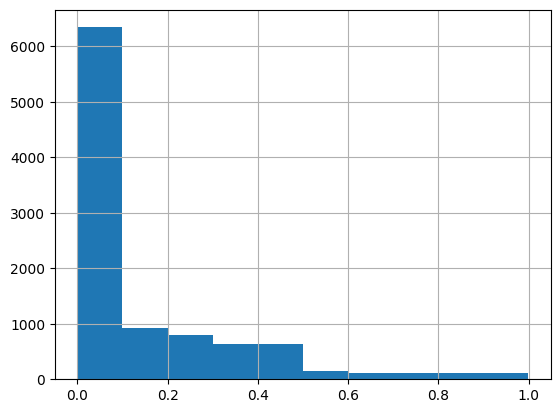

In [18]:
# make column difference which calculates the variance across colujmns 0:K
# calcualte absolute difference between 0:K columns 
cell_type_psi_df["difference"] = cell_type_psi_df[0] - cell_type_psi_df[1]
cell_type_psi_df["difference"] = np.abs(cell_type_psi_df["difference"])
cell_type_psi_df["difference"].hist()

<Axes: xlabel='difference', ylabel='Count'>

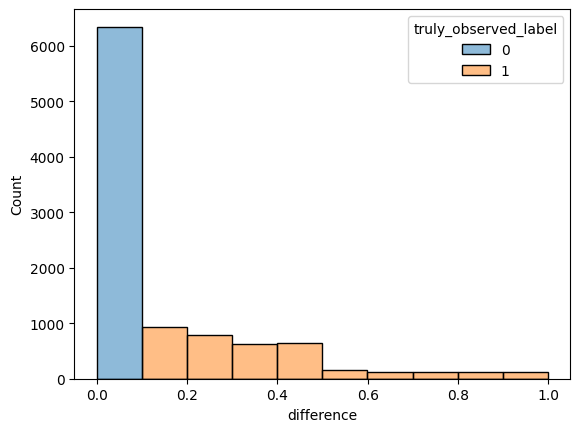

In [19]:
# add truly_observed_label column to cell_type_psi_df indicating positive if abs(difference) > 0.15
cell_type_psi_df["truly_observed_label"] = np.where(abs(cell_type_psi_df["difference"]) > 0.1, 1, 0)
# plot difference coloured by truly_observed_label
sns.histplot(x="difference", bins=10, hue="truly_observed_label", data=cell_type_psi_df)

In [20]:
# cell_type_psi_df drop original sample_label and rename truly observed label to sample_label and amke it categorical
cell_type_psi_df = cell_type_psi_df.drop(columns=["sample_label"])
cell_type_psi_df = cell_type_psi_df.rename(columns={"truly_observed_label": "sample_label"})
cell_type_psi_df["sample_label"] = cell_type_psi_df["sample_label"].astype('category')
cell_type_psi_df.head()

,0,1,new_junction_id_index,Cluster,difference,sample_label
0,0.459928,0.459928,0,3,0.000000,0
1,0.080145,0.080145,1,3,0.000000,0
2,0.459928,0.459928,2,3,0.000000,0
0,0.016673,0.229462,3,19,0.212789,1
2,0.016673,0.229462,4,19,0.212789,1


In [21]:
cell_type_psi_df.tail()

,0,1,new_junction_id_index,Cluster,difference,sample_label
2,0.020414,0.095503,9946,15467,0.075089,0
1,0.700414,0.188249,9947,26765,0.512165,1
2,0.092422,0.136833,9948,1268,0.044411,0
1,0.382076,0.970905,9949,8836,0.588829,1
1,0.967353,0.967353,9950,41223,0.000000,0


In [22]:
# make dataframe using the following columsn 
sim_junc_counts_flat = pd.DataFrame({"cell_id_index": sim_juncs_counts.row, "new_junction_id_index": sim_juncs_counts.col, "new_junc_count": sim_juncs_counts.data})
sim_junc_counts_flat.head()

# also add new cell type column 
sim_junc_counts_flat["new_cell_type"] = np.array(cell_types[sim_junc_counts_flat["cell_id_index"]])
sim_junc_counts_flat.head()

,cell_id_index,new_junction_id_index,new_junc_count,new_cell_type
0,0,0,63.0,1
1,0,1,15.0,1
2,0,2,67.0,1
3,0,3,0.0,1
4,0,4,3.0,1


In [23]:
# update junction counts in final_data object to be the simulated counts 
final_data = final_data.merge(sim_junc_counts_flat, on = ["cell_id_index", "new_junction_id_index"])
final_data.head()

,cell_id_index,junction_id_index,junc_count,cluster_count,clustminjunc,juncratio,cell_id,cell_type,junction_id,Cluster,gene_id_x,gene_id_y,new_junction_id_index,new_junc_count,new_cell_type
0,0,0,25.0,132,107.0,0.189394,SRR1805814,E14.5,1_36560920_36563114,3,ENSMUSG00000001138.14,ENSMUSG00000001138.14,0,63.0,1
1,13,0,43.0,112,69.0,0.383929,SRR1805827,P15,1_36560920_36563114,3,ENSMUSG00000001138.14,ENSMUSG00000001138.14,0,48.0,0
2,16,0,55.0,154,99.0,0.357143,SRR1812033,E16.5,1_36560920_36563114,3,ENSMUSG00000001138.14,ENSMUSG00000001138.14,0,76.0,1
3,12,0,34.0,87,53.0,0.390805,SRR1805826,P15,1_36560920_36563114,3,ENSMUSG00000001138.14,ENSMUSG00000001138.14,0,39.0,1
4,8,0,42.0,106,64.0,0.396226,SRR1805822,P110,1_36560920_36563114,3,ENSMUSG00000001138.14,ENSMUSG00000001138.14,0,49.0,0


In [24]:
# remove gene_id_x column and rename gene_id_y to just gene_id
final_data.drop(columns = ["gene_id_x"], inplace = True)
final_data.rename(columns = {"gene_id_y": "gene_id"}, inplace = True)

In [25]:
sim_data = final_data.copy() 
# drop the old junction counts and junction id index
sim_data.drop(columns = ["junc_count", "junction_id_index"], inplace = True)
# rename columns new_junction_id_index and new_junc_count to junction_id_index and junc_count
sim_data.rename(columns = {"new_junction_id_index": "junction_id_index", "new_junc_count": "junc_count"}, inplace = True)
sim_data.head()

,cell_id_index,cluster_count,clustminjunc,juncratio,cell_id,cell_type,junction_id,Cluster,gene_id,junction_id_index,junc_count,new_cell_type
0,0,132,107.0,0.189394,SRR1805814,E14.5,1_36560920_36563114,3,ENSMUSG00000001138.14,0,63.0,1
1,13,112,69.0,0.383929,SRR1805827,P15,1_36560920_36563114,3,ENSMUSG00000001138.14,0,48.0,0
2,16,154,99.0,0.357143,SRR1812033,E16.5,1_36560920_36563114,3,ENSMUSG00000001138.14,0,76.0,1
3,12,87,53.0,0.390805,SRR1805826,P15,1_36560920_36563114,3,ENSMUSG00000001138.14,0,39.0,1
4,8,106,64.0,0.396226,SRR1805822,P110,1_36560920_36563114,3,ENSMUSG00000001138.14,0,49.0,0


In [26]:
# update cluster_count to be the sum of junction_id_index in each Cluster for each cell
new_clust_counts = sim_data.groupby(["cell_id_index", "Cluster"]).agg({"junc_count": "sum"}).reset_index()
# update column to be cluster_count 
new_clust_counts.rename(columns = {"junc_count": "cluster_count"}, inplace = True)
sim_data.drop(columns = ["cluster_count"], inplace = True)
# merge new_clust_counts with sim_data
sim_data = sim_data.merge(new_clust_counts, on = ["cell_id_index", "Cluster"])

<Axes: xlabel='junc_ratio', ylabel='Count'>

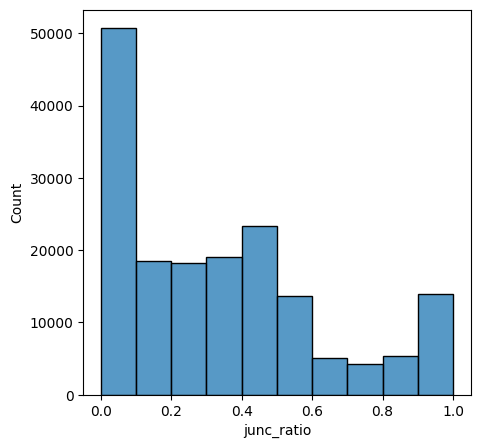

In [27]:
# update juncratio 
sim_data["clustminjunc"] = sim_data["cluster_count"] - sim_data["junc_count"]
sim_data["junc_ratio"] = sim_data["junc_count"] / sim_data["cluster_count"]

# make histogram of junc_ratio
plt.figure(figsize=(5,5))
sns.histplot(sim_data.junc_ratio, bins=10)

In [28]:
sim_data

,cell_id_index,clustminjunc,juncratio,cell_id,cell_type,junction_id,Cluster,gene_id,junction_id_index,junc_count,new_cell_type,cluster_count,junc_ratio
0,0,82.0,0.189394,SRR1805814,E14.5,1_36560920_36563114,3,ENSMUSG00000001138.14,0,63.0,1,145.0,0.434483
1,13,71.0,0.383929,SRR1805827,P15,1_36560920_36563114,3,ENSMUSG00000001138.14,0,48.0,0,119.0,0.403361
2,16,96.0,0.357143,SRR1812033,E16.5,1_36560920_36563114,3,ENSMUSG00000001138.14,0,76.0,1,172.0,0.441860
3,12,43.0,0.390805,SRR1805826,P15,1_36560920_36563114,3,ENSMUSG00000001138.14,0,39.0,1,82.0,0.475610
4,8,67.0,0.396226,SRR1805822,P110,1_36560920_36563114,3,ENSMUSG00000001138.14,0,49.0,0,116.0,0.422414
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173044,12,1.0,0.285714,SRR1805826,P15,18_26155773_26276927,41223,ENSMUSG00000117604.2,9950,7.0,1,8.0,0.875000
173045,1,0.0,0.000000,SRR1805815,E14.5,18_26155773_26276927,41223,ENSMUSG00000117604.2,9950,1.0,0,1.0,1.000000
173046,4,1.0,0.000000,SRR1805818,P4,18_26155773_26276927,41223,ENSMUSG00000117604.2,9950,4.0,0,5.0,0.800000
173047,15,0.0,0.500000,SRR1805829,P7,18_26155773_26276927,41223,ENSMUSG00000117604.2,9950,9.0,0,9.0,1.000000


### Prep data for model training 

In [29]:
if device == torch.device('cuda'):
    torch.set_default_tensor_type('torch.cuda.FloatTensor')

In [30]:
cell_index_tensor, junc_index_tensor, my_data = llc.make_torch_data(sim_data, **float_type)

The number of cells going into training data is:
18
18


In [31]:
cell_type_psi_df

,0,1,new_junction_id_index,Cluster,difference,sample_label
0,0.459928,0.459928,0,3,0.000000,0
1,0.080145,0.080145,1,3,0.000000,0
2,0.459928,0.459928,2,3,0.000000,0
0,0.016673,0.229462,3,19,0.212789,1
2,0.016673,0.229462,4,19,0.212789,1
...,...,...,...,...,...,...
2,0.020414,0.095503,9946,15467,0.075089,0
1,0.700414,0.188249,9947,26765,0.512165,1
2,0.092422,0.136833,9948,1268,0.044411,0
1,0.382076,0.970905,9949,8836,0.588829,1


In [32]:
clust_labels_only = cell_type_psi_df[["Cluster", "sample_label"]].drop_duplicates()
simple_data = sim_data[["cell_id_index", "Cluster", "cell_type", "junction_id_index", "junc_ratio", "junc_count", "cluster_count"]]
# merge with clust_labels_only 
simple_data = simple_data.merge(clust_labels_only, on = ["Cluster"])
# get true PSI for each Cluster 
simple_data.head()

,cell_id_index,Cluster,cell_type,junction_id_index,junc_ratio,junc_count,cluster_count,sample_label
0,0,3,E14.5,0,0.434483,63.0,145.0,0
1,13,3,P15,0,0.403361,48.0,119.0,0
2,16,3,E16.5,0,0.441860,76.0,172.0,0
3,12,3,P15,0,0.475610,39.0,82.0,0
4,8,3,P110,0,0.422414,49.0,116.0,0


In [33]:
# update cell_type column in simple data to what it is in cell_ids_conversion using cell_id_index and make sure it's a category
simple_data.drop(columns = ["cell_type"], inplace = True)
simple_data = simple_data.merge(cell_ids_conversion, on = ["cell_id_index"])
simple_data["cell_type"] = simple_data["cell_type"].astype('category')
simple_data.head()

,cell_id_index,Cluster,junction_id_index,junc_ratio,junc_count,cluster_count,sample_label,cell_id,cell_type
0,0,3,0,0.434483,63.0,145.0,0,SRR1805814,2
1,13,3,0,0.403361,48.0,119.0,0,SRR1805827,1
2,16,3,0,0.441860,76.0,172.0,0,SRR1812033,2
3,12,3,0,0.475610,39.0,82.0,0,SRR1805826,2
4,8,3,0,0.422414,49.0,116.0,0,SRR1805822,1


In [34]:
def quick_clust_plot(clust, simple_data, num_cols=3, plot_states_arb=True):
    
    simple_data_junc = simple_data[simple_data["Cluster"] == clust]
    # make violin plot with jitter 
    print(simple_data_junc.cell_type.value_counts())
    sample_label = simple_data_junc.sample_label.unique()[0]
    
    # if plot_states_arb = True then instead of real cell types make dummy variable and use that for cell type
    if plot_states_arb:
        # get unique values in cell type and mapping to a number 
        cell_types = simple_data_junc.cell_type.unique()
        cell_type_map = dict(zip(cell_types, range(len(cell_types))))
        simple_data_junc["cell_type"] = simple_data_junc["cell_type"].map(cell_type_map)
        #make sure new values in cell_Type are string
        simple_data_junc["cell_type"] = simple_data_junc["cell_type"].astype(str)
    
    plt.figuresize=(6, 6)

    # choose three distrinct colours to use for junction_id_index hue 
    colors = sns.color_palette("husl", num_cols)

    # use colors in violinplot
    sns.violinplot(data = simple_data_junc, x = "junc_ratio", y = "cell_type", hue="junction_id_index", palette=colors)

    # make xlim -1 to 1.1
    plt.xlim(-0.2, 1.2)
    # add sample_label to title 
    plt.title(sample_label + " label for cluster:" + str(clust), fontsize=16)
    # set x axis label to "Junction Usage Ratio (PSI)"
    plt.xlabel("Junction Usage Ratio (PSI)", fontsize=20)
    plt.ylabel("Cell Type Group", fontsize=20)
    # increase x and y tick label size to 14
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    # put legend outside the plot
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=20)
    plt.show()

In [35]:
simple_data

,cell_id_index,Cluster,junction_id_index,junc_ratio,junc_count,cluster_count,sample_label,cell_id,cell_type
0,0,3,0,0.434483,63.0,145.0,0,SRR1805814,2
1,13,3,0,0.403361,48.0,119.0,0,SRR1805827,1
2,16,3,0,0.441860,76.0,172.0,0,SRR1812033,2
3,12,3,0,0.475610,39.0,82.0,0,SRR1805826,2
4,8,3,0,0.422414,49.0,116.0,0,SRR1805822,1
...,...,...,...,...,...,...,...,...,...
184573,12,41223,9950,0.875000,7.0,8.0,0,SRR1805826,2
184574,1,41223,9950,1.000000,1.0,1.0,0,SRR1805815,1
184575,4,41223,9950,0.800000,4.0,5.0,0,SRR1805818,1
184576,15,41223,9950,1.000000,9.0,9.0,0,SRR1805829,1


In [36]:
# rename 0 to neg and 1 to pos in simple_data["sample_label"]
simple_data["sample_label"] = simple_data["sample_label"].replace({0: "neg", 1: "pos"})
simple_data["sample_label"] = simple_data["sample_label"].astype('category')

/scratch/ipykernel_194041/2608993514.py:2: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  simple_data["sample_label"] = simple_data["sample_label"].replace({0: "neg", 1: "pos"})


/scratch/ipykernel_194041/2183167184.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  simple_data_junc["cell_type"] = simple_data_junc["cell_type"].map(cell_type_map)
/scratch/ipykernel_194041/2183167184.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  simple_data_junc["cell_type"] = simple_data_junc["cell_type"].astype(str)
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the a

33566
cell_type
1    27
2    27
Name: count, dtype: int64


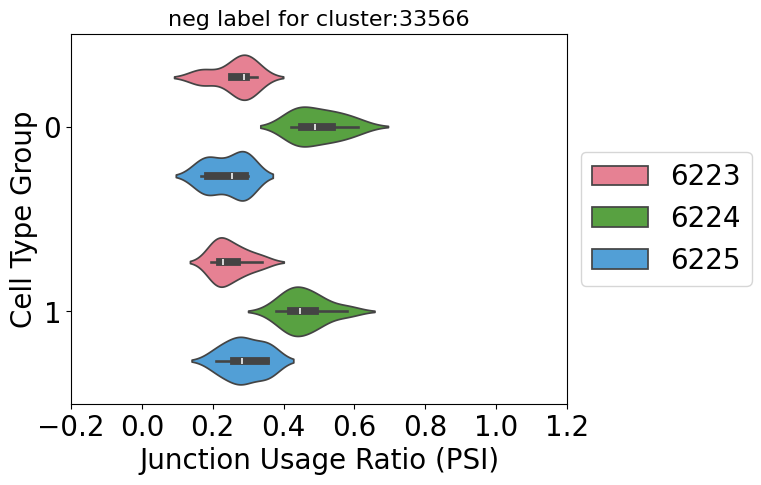

In [37]:
# let's visualize junction usage ratios for a given custer 
# sample clust from simple_data.Cluster.unique()
clust = np.random.choice(simple_data.Cluster.unique())
print(clust)
#sim.quick_clust_plot(clust, simple_data)
quick_clust_plot(clust, simple_data)

In [38]:
indices = torch.tensor(sim_data[['cell_id_index', 'junction_id_index']].to_numpy().T, dtype=torch.long)
values = torch.tensor(sim_data['junc_count'].to_numpy(), dtype=torch.float)
# Determine the size of the tensor
num_cells = sim_data['cell_id_index'].max() + 1
num_junctions = sim_data['junction_id_index'].max() + 1
size = (num_cells, num_junctions)
# Create a sparse tensor
y_tensor = torch.sparse_coo_tensor(indices, values, size)

In [39]:
indices_counts = torch.tensor(sim_data[['cell_id_index', 'junction_id_index']].to_numpy().T, dtype=torch.long)
values_counts = torch.tensor(sim_data['cluster_count'].to_numpy(), dtype=torch.float)
# Determine the size of the tensor
num_cells_counts = sim_data['cell_id_index'].max() + 1
num_junctions_counts = sim_data['junction_id_index'].max() + 1
size_counts = (num_cells_counts, num_junctions_counts)
# Create a sparse tensor
total_counts_tensor = torch.sparse_coo_tensor(indices_counts, values_counts, size_counts)

In [40]:
# save full dataset y_tensor and total_counts_tensor 
full_y_tensor = y_tensor
full_total_counts_tensor = total_counts_tensor

In [41]:
# remake junction counts and cluster counts sp.coo_matrix for masking analysis
indices = (sim_data.cell_id_index, sim_data.junction_id_index)
junc_counts = sp.coo_matrix((sim_data.junc_count, indices))
cluster_counts = sp.coo_matrix((sim_data.cluster_count, indices))

In [42]:
# import factor model from beta-dirichlet-factor
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-private/src/evaluations')
import masking
from masking import *

# import reload 
from importlib import reload
reload(masking)

<module 'masking' from '/gpfs/commons/home/kisaev/Leaflet-private/src/evaluations/masking.py'>

In [43]:
#1. get masked matrix using intron cluster counts for this mouse brain data 

# same masking percentage for all three matrices but generating three different masks
masking_percs = [0.05, 0.1, 0.2]
masks_list = []
seeds_used = []

print("+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++")
print("Getting masked matrix for each masking percentage")
print("+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++")

for perc_mask in masking_percs:
    print("The masking percentage is: " + str(perc_mask))
    masked_matrix, seed = generate_mask(cluster_counts, mask_percentage = perc_mask, randomize_seed = True)
    seeds_used.append(seed)
    # append to masks_list
    masks_list.append(masked_matrix)

#2. get junction and intron cluster count matrices with masked values 
masked_counts = []

print("+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++")
print("Getting junction and intron cluster count matrices with masked values")
print("+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++")

for i in range(len(masking_percs)):
    print("The masking percentage is: " + str(masking_percs[i]))
    masked_junction_counts, masked_intron_clusts = apply_mask(junc_counts, cluster_counts, masks_list[i])
    # appent masked junction and intron cluster counts to list
    masked_counts.append((masked_junction_counts, masked_intron_clusts))

#3. get input files for factor model (junction and intron cluster sparse tensor)
model_input_files = [] 

print("+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++")
print("Getting input files for factor model")
print("+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++")

for i in range(len(masking_percs)):
    print("The masking percentage is: " + str(masking_percs[i]))
    masked_junction_counts, masked_intron_clusts = masked_counts[i]
    # get y_tensor and total_counts_tensor via prep_model_input function
    y_tensor, total_counts_tensor = prep_model_input(masked_junction_counts, masked_intron_clusts)
    # append to model_input_files list
    model_input_files.append((y_tensor, total_counts_tensor))

+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Getting masked matrix for each masking percentage
+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
The masking percentage is: 0.05
The seed is:  273718
[ 46861  67045  19950  69059 149827 100486 111835 160877  92211 123802
 136596 111855  27475 120375  19806  51113  36374  15220  71623  28536
 121265 157696 145389  55472 148770  69945  52841 140438  16130 150228
 169433  75814 118990  88306 119551 105273 102999 150212 141260  95310
 150355 144692  59030 120744  83397  98599  38293  11510 119979  22359]
Number of entries (junction-cell pairs) masked:  8652.0
The masking percentage is: 0.1
The seed is:  858547
[ 70103 131499  49043  82615 107921  33639 153093 117821 146000 102343
  49869 107925  36862  64495 113040 164744  34154 116174  68917 169219
  96072  45650  27141  37288  62512  37330 148030  54486  30605  20948
  79458  68050  24862 124620  31679  73072 121508 141184   1810 154672
 166821  

/gpfs/commons/home/kisaev/Leaflet-private/src/evaluations/masking.py:141: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:274.)
  indices = torch.tensor(np.nonzero(masked_intron_clusts), dtype=torch.long)


The masking percentage is: 0.1
The masking percentage is: 0.2


In [44]:
# Now can run factor model on masked data
Ks = [2, 5, 20, 100 , 500]
all_Ks_results = {}
# Seeds used for masking 
seeds_used 

# define list of seeds for training factor model 
seeds = [42, 102, 300] #, 102]

# set concentration value to infinity 
init_conc = float('inf')
init_conc = None

print("Learning rate seems to matter especially when K > 100, consider reducing it if running into NaN issues!")

for k in tqdm(Ks):
    
    print("------------------------------------------------")
    print("Running factor model for K = " + str(k))
    print("------------------------------------------------")
    
    # now also iterate over masking percentages 
    for i in range(len(masking_percs)):
        print("The masking percentage is: " + str(masking_percs[i]))
        print("++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++")
        y_tensor, total_counts_tensor = model_input_files[i]
        # run factor model
        masked_results = factor_model.main(y_tensor, total_counts_tensor, num_initializations=3, use_global_prior=True, input_conc=init_conc, K=k, seeds=seeds,loss_plot=False, num_epochs=50, lr = 0.01, save_to_file = False)
        # save results to dictionary
        all_Ks_results[(k, masking_percs[i])] = masked_results

Learning rate seems to matter especially when K > 100, consider reducing it if running into NaN issues!


  0%|          | 0/5 [00:00<?, ?it/s]

------------------------------------------------
Running factor model for K = 2
------------------------------------------------
The masking percentage is: 0.05
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Using prior for a and b per junction to model average behaviour!
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Using a Beta-binomial distribution with concentration parameter None.
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
No input concentration parameter provided. Using default Gamma(2.0, 2.0) to initialize and learn bb concentration.
+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Initialization 1 with seed 42
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Define the guide using AutoDiagonalNormal based on the model stru

INFO:root:Elbo loss: 722075.9084629295


Epoch 40, Elbo loss: 734739.4324407058
Sample from the guide (posterior)
Calculate summary statistics
Summary statistics for _AutoDiagonalNormal_latent: {'mean': array([ 0.19988003, -0.07035422,  0.21856637, ..., -0.11384008,
       -0.10127006, -0.10193897], dtype=float32), 'std': array([0.08513986, 0.1585925 , 0.14603439, ..., 0.09623025, 0.08750701,
       0.09022386], dtype=float32), '5%': array([ 0.04689934, -0.3266489 , -0.01253116, ..., -0.2608334 ,
       -0.25851758, -0.22167294]), '95%': array([0.32100551, 0.163019  , 0.44930911, ..., 0.06227235, 0.05349266,
       0.05407469])}
Summary statistics for data: {'mean': array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
       13., 14., 15., 16., 17.], dtype=float32), 'std': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0.], dtype=float32), '5%': array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
       13., 14., 15., 16., 17.]), '95%': array([ 0.,  1.,

...

Epoch 40, Elbo loss: 9820055.93817376
Sample from the guide (posterior)
Calculate summary statistics
Summary statistics for _AutoDiagonalNormal_latent: {'mean': array([ 0.10704983,  0.21388781,  0.5419125 , ...,  0.47304982,
       -0.4299315 ,  0.30035937], dtype=float32), 'std': array([0.09353124, 0.09007986, 0.09098367, ..., 0.15614416, 0.15057805,
       0.14689034], dtype=float32), '5%': array([-0.03433315,  0.07528532,  0.39822765, ...,  0.21828917,
       -0.67732993,  0.08229212]), '95%': array([ 0.25744012,  0.37850458,  0.69034847, ...,  0.7144    ,
       -0.21300742,  0.51076303])}
Summary statistics for data: {'mean': array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
       13., 14., 15., 16., 17.], dtype=float32), 'std': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0.], dtype=float32), '5%': array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
       13., 14., 15., 16., 17.]), '95%': array([ 0.,

INFO:root:Elbo loss: 9133149.264338931


Epoch 40, Elbo loss: 9814682.706222434
Sample from the guide (posterior)
Calculate summary statistics


100%|██████████| 5/5 [14:56<00:00, 179.28s/it]

Summary statistics for _AutoDiagonalNormal_latent: {'mean': array([ 1.4118262e-01, -2.9424415e-04,  1.0543288e-01, ...,
       -3.9502466e-01,  5.0453937e-01, -4.4263923e-01], dtype=float32), 'std': array([0.0732071 , 0.07971399, 0.09531938, ..., 0.16400075, 0.17893454,
       0.1682039 ], dtype=float32), '5%': array([-0.00176298, -0.15029159, -0.03332375, ..., -0.66622284,
        0.24438475, -0.6942099 ]), '95%': array([ 0.24358919,  0.10837964,  0.2498405 , ..., -0.13404578,
        0.81432141, -0.15310325])}
Summary statistics for data: {'mean': array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
       13., 14., 15., 16., 17.], dtype=float32), 'std': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0.], dtype=float32), '5%': array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
       13., 14., 15., 16., 17.]), '95%': array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
       13., 14., 15., 

In [45]:
# Get pearson correlation and l1 error between true and inferred parameters (PSI)
masked_perf = []

for k in Ks:
    for perc_mask in masking_percs:
        print("Calculating performance for K = " + str(k) + " and masking percentage = " + str(perc_mask))
        masked_results = all_Ks_results[(k, perc_mask)]        
        for res in masked_results:
            # get seed that was used 
            seed = res['seed']

            # get latent variables
            psi = res['latent_vars']["psi"] # psi is the probability of a junction being used in a cluster
            assign_post=res['latent_vars']["assign"]

            # get K 
            K = psi.shape[0]
            J = psi.shape[1]

            # get scores 
            mask_matrix_used = masks_list[i]
            l1, r, l2, rmse, llk = evaluate_model(junc_counts.toarray(), cluster_counts.toarray(), psi, assign_post, mask_matrix_used)

            # get num epochs trained for 
            nepoch = len(res["losses"])

            # save to list 
            masked_perf.append([seed, l1, r, l2, rmse, llk, K, perc_mask, J, nepoch])

Calculating performance for K = 2 and masking percentage = 0.05


IndexError: index 23 is out of bounds for axis 1 with size 18

In [ ]:
import pandas as pd 
# make masked_perf a dataframe 
masked_perf_df = pd.DataFrame(masked_perf, columns=["seed", "l1", "r", "l2", "rmse", "llk", "K",  "perc_masked" , "J", "num_epochs"])
# get current date and time to add to file name for saving 
from datetime import datetime
now = datetime.now()
file_name = "simulated_masked_perf_df_" + now.strftime("%Y%m%d_%H%M%S")
# save to compressed csv
masked_perf_df.to_csv(file_name, compression='gzip')

In [ ]:
masked_perf_df.head()

In [ ]:
# make new column combining seed and perc_masked
masked_perf_df['seed_perc_masked'] = masked_perf_df['seed'].astype(str) + "_" + masked_perf_df['perc_masked'].astype(str)
masked_perf_df.head()

# there should be 2 seperate seed_perc_masked values for each K because there were two seperate masks used 
masked_perf_df['seed_perc_masked'].value_counts()

In [ ]:
# make boxplot of l1 error for each K and masking percentage
# sns.set_style("whitegrid")
import seaborn as sns
import matplotlib.pyplot as plt 

# make boxplot for r 
sns.set_style("whitegrid")
sns.set_context("paper")
sns.set(font_scale=1.5)
plt.figure(figsize=(5, 5))

ax = sns.boxplot(x="K", y="l1", data=masked_perf_df, palette="Set1", hue="perc_masked")
ax.set_xlabel("K")
ax.set_ylabel("L1")
ax.set_title("Spearman L1 for masked data")

# put legend on the outside 
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()

print(masked_perf_df.l1.min())

In [ ]:
# make boxplot for r 
sns.set_style("whitegrid")
sns.set_context("paper")
sns.set(font_scale=1.5)
plt.figure(figsize=(5, 5))

ax = sns.boxplot(x="K", y="r", data=masked_perf_df, palette="Set1", hue="perc_masked")
ax.set_xlabel("K")
ax.set_ylabel("r")
ax.set_title("Spearman r for masked data")
# put legend on the outside 
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()
print(masked_perf_df.r.max())

In [ ]:
# make boxplot for rmse 
sns.set_style("whitegrid")
sns.set_context("paper")
sns.set(font_scale=1.5)
plt.figure(figsize=(5, 5))

ax = sns.boxplot(x="K", y="rmse", data=masked_perf_df, palette="Set1", hue="perc_masked")
ax.set_xlabel("K")
ax.set_ylabel("RMSE")
ax.set_title("RMSE on masked data")
# put legend on the outside 
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()
print(masked_perf_df.rmse.min())

In [ ]:
# make boxplot for rmse 
sns.set_style("whitegrid")
sns.set_context("paper")
sns.set(font_scale=1.5)
plt.figure(figsize=(5, 5))

ax = sns.boxplot(x="K", y="llk", data=masked_perf_df, palette="Set1", hue="perc_masked")
ax.set_xlabel("K")
ax.set_ylabel("llk")
ax.set_title("llk on masked data")
# put legend on the outside 
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()
print(masked_perf_df.rmse.min())

### Train the Full Model!!

In [ ]:
reload(factor_model)
best_K = 2
K = best_K
#input_conc = 50
# set input_conc to inf
input_conc = None
all_results = factor_model.main(full_y_tensor, full_total_counts_tensor, num_initializations=1, use_global_prior=True, input_conc=input_conc, K=K, lr=0.1, loss_plot=True, num_epochs=500, save_to_file = False)

In [ ]:
losses = [result["losses"][-1] for result in all_results]
# make a quick plot of the losses
plt.plot(losses)
plt.xlabel("Initialization")
plt.ylabel("Final Loss")
# make each loss value with a dot 
plt.scatter(range(len(losses)), losses)
# mark the lowest loss red
plt.scatter(np.argmin(losses), np.min(losses), color="red")

# get the index of initialization with the lowest loss
best_init = np.argmin(losses)
print("The best initialization was: ", best_init)

# extract latent variables for just first seed used 
latent_vars = all_results[best_init]['summary_stats'] 

pi = latent_vars["pi"]["mean"] # overall contribution of each factor to cell population, one value per k
dir_conc = latent_vars["dir_conc"]["mean"] # one scaling value 
assign_post = latent_vars["assign"]["mean"]
psis = latent_vars["psi"]["mean"] # psi is the probability of a junction being used in a cluster
a = latent_vars["a"]["mean"] 
b = latent_vars["b"]["mean"] 
bb_conc = latent_vars["bb_conc"]["mean"] # concentration parameter for beta-binomial distribution

print(a)
print(b)

print("The inferred concentration parameter is: " + str(dir_conc))
print("The inferred pi parameter is: " + str(pi))
print("The inferred bb_conc parameter is: " + str(bb_conc))

plot_bb=True

In [ ]:
cell_types_id = sim_data[["cell_id", "cell_id_index", "new_cell_type"]].drop_duplicates()
# reorder by cell_id_index
cell_types_id = cell_types_id.sort_values(by = ["cell_id_index"])
cell_types_id.head()

In [ ]:
cell_types_id.new_cell_type.value_counts()

In [ ]:
# from dictionary of latent variables, get the assign_post for each iteration and add to a dataframe
assign_post = []
for i in range(len(latent_results)):
    assign_post_df = pd.DataFrame(latent_results[i]["assign_post"])
    assign_post_df["new_cell_type"] = cell_types_id.new_cell_type.values
    print(assign_post_df.new_cell_type.value_counts())
    assign_post.append(latent_results[i]["assign_post"])

In [ ]:
import seaborn as sns

color_palette = sns.color_palette("Set1", n_colors=len(cell_types_id['new_cell_type'].unique()))
# Create a color bar legend
legend = sns.color_palette(palette=color_palette, as_cmap=True)

# Obtain cell type labels for every cell in the matrix also 
unique_cell_types = cell_types_id['new_cell_type'].unique()
num_unique_types = len(unique_cell_types)
colors = sns.color_palette('Set1', n_colors=num_unique_types)  # You can use any color palette
cell_types = cell_types_id.new_cell_type.values

# create colours for each cell type 
cell_type_colors = {new_cell_type: color for new_cell_type, color in zip(unique_cell_types, colors)}
row_colors = [cell_type_colors[new_cell_type] for new_cell_type in cell_types]

for i in range(len(assign_post)):
    cluster = sns.clustermap(
        data=assign_post[i],
        method='complete',
        cmap="viridis",
        annot=False,
        fmt=".2f",
        yticklabels=False,
        figsize=(6, 6),
        center=0,
        row_colors=row_colors,  # Apply row colors
        cbar_kws={'label': 'Post assignment'} 
        )
    cluster.cax.set_ylabel('Post assignment', size=8)
    # add title 
    #cluster.ax_heatmap.set_title('Posterior assignment probabilities for iteration number ' + str(i))
    # Increase font size for color bar tick labels:
    cbar_ax = cluster.cax
    for label in cbar_ax.yaxis.get_ticklabels():
        label.set_size(8)

In [ ]:
from umap.umap_ import UMAP
reducer = UMAP()

In [ ]:
umaps = []

for i in range(len(assign_post)):
    print("Running UMAP for iteration number " + str(i))
    # make UMAP using average assign_post across seeds and color points by cell_type 
    embedding = reducer.fit_transform(assign_post[i])
    umaps.append(embedding)

In [ ]:
# make function for plotting UMAPs 
def umap_plot(umap, cell_type_colors, cell_types):
    sns.set_style("whitegrid")
    sns.set_context("paper")
    plt.figure(figsize=(4, 4))    
    plt.scatter(umap[:, 0], umap[:, 1],
        c=[cell_type_colors[cell_type] for cell_type in cell_types],
        s=8, alpha=0.3)
    # xlab 
    plt.xlabel("UMAP 1")
    # ylab
    plt.ylabel("UMAP 2")

In [ ]:
for i in range(len(umaps)):
    print("Plotting UMAP for iteration number " + str(i))
    umap_plot(umaps[i], cell_type_colors, cell_types)

In [ ]:
# loop through all restults and make barplot of contribute of each factor to cell population pi

for i in range(len(latent_results)):
    pi = latent_results[i]["pi"]
    pi_df = pd.DataFrame(pi, columns = ["pi"])
    pi_df["factor"] = "Factor" + pi_df.index.astype(str)
    pi_df["iteration"] = i
    pi_df["iteration"] = pi_df["iteration"].astype(str)
    pi_df["factor"] = pi_df["factor"].astype(str)
    pi_df["pi"] = pi_df["pi"].astype(float)
    # order by pi
    pi_df = pi_df.sort_values(by = ["pi"], ascending = False)
    # prnt the factors with contribution greater than 0.01
    print(pi_df[pi_df["pi"] > 0.01])    
    # make barplot
    sns.set_style("whitegrid")
    sns.set_context("paper")
    plt.figure(figsize=(8, 6))
    ax = sns.barplot(x="factor", y="pi", data=pi_df, color="grey") #, palette="Set1")
    # draw a line at 0.01 
    ax.axhline(0.01, color='grey', linestyle='--')
    ax.set_xlabel("Factor")
    # remove xaxis ticks 
    ax.set_xticks([])
    ax.set_ylabel("Contribution to cell population")
    ax.set_title("Contribution of each factor to cell population for iteration number " + str(i))
    plt.show()

In [ ]:
# now let's look at psis 
psis = latent_results[0]["psis"]
psis.shape # K by J 

# rotate so it's J by K
psis = psis.T

# now convert to dataframe
psis_df = pd.DataFrame(psis)
psis_df["junction_id_index"] = psis_df.index

# calculate junction standard deviation across the K factors 
psis_df["std"] = psis_df[psis_df.columns[0:K]].std(axis=1)

# sort by std
psis_df = psis_df.sort_values(by = ["std"], ascending = False)
psis_df.head()

In [ ]:
latent_results

In [ ]:
# get the top 10 junctions with the highest standard deviation across the K factors
top_juncs = psis_df.head(10)
top_juncs

In [ ]:
# Functions for differential splicing analysis 
def log_beta_torch(a, b):
    
    """
    Computes the logarithm of the beta function for given alpha and beta parameters.

    Args:
    a (Tensor): Alpha parameters of the beta distribution.
    b (Tensor): Beta parameters of the beta distribution.

    Returns:
    Tensor: Logarithm of the beta function evaluated at (a, b).
    """
        
    return torch.lgamma(a) + torch.lgamma(b) - torch.lgamma(a + b)

def score_torch(a, b):
    
    """
    Computes the differential splicing score as the difference between the sum of log beta functions
    for each cell state and the log beta function of summed parameters across all states.

    Args:
    a (Tensor): Alpha parameters for each cell state.
    b (Tensor): Beta parameters for each cell state.

    Returns:
    Tensor: Differential splicing score.
    """
    
    return log_beta_torch(a, b).sum() - log_beta_torch(a.sum(), b.sum())

# Add functionality for getting score q-value to measure significance of differential splicing
def differential_splicing_torch(PSI_kj, a_j, b_j, bb_conc):

    """
    Analyzes differential splicing across cell states by comparing local splicing levels to global averages.

    Args:
    PSI_kj (Tensor or array): Posterior mean inclusion levels for each junction in each cell state.
    a_j (Tensor or array): Alpha parameters from a global perspective for each junction.
    b_j (Tensor or array): Beta parameters from a global perspective for each junction.
    bb_conc (Tensor or array): Global beta-binomial concentration parameter.

    Returns:
    tuple: Approximate log Bayes factor (ALBF) indicating likelihood of differential splicing across cell states,
           and the contribution score for each cell state to the overall variability in splicing.

    Notes:
    - ALBF: Higher values suggest a higher likelihood of differential splicing across cell states.
    - Factor contribution score: Measures the contribution of each cell state's PSI to the total variability,
      scaled by the beta-binomial concentration parameter. It is useful for identifying specific states
      with significant deviations from the global behavior.
    """
    
    # Ensure inputs are torch tensors
    PSI_kj = torch.tensor(PSI_kj, dtype=torch.float32) if not isinstance(PSI_kj, torch.Tensor) else PSI_kj
    a_j = torch.tensor(a_j, dtype=torch.float32) if not isinstance(a_j, torch.Tensor) else a_j
    b_j = torch.tensor(b_j, dtype=torch.float32) if not isinstance(b_j, torch.Tensor) else b_j
    bb_conc = torch.tensor(bb_conc, dtype=torch.float32) if not isinstance(bb_conc, torch.Tensor) else bb_conc
    
    # Compute global average PSI using junction-specific parameters
    global_avg_psi = a_j / (a_j + b_j)

    # Calculate alpha and beta values for each cell state based on the global shape parameters
    alpha_kj = PSI_kj * a_j
    beta_kj = (1 - PSI_kj) * b_j

    # Calculate ALBF score for junction 
    ALBF = score_torch(alpha_kj, beta_kj)

    # Compute factor contribution scores
    factor_contributes = ((PSI_kj - global_avg_psi)**2) * bb_conc 

    return ALBF, factor_contributes 

In [ ]:
simple_data[simple_data["junction_id_index"] == 911]

In [ ]:
clust = np.random.choice(simple_data.Cluster.unique())
print(clust)
#sim.quick_clust_plot(clust, simple_data)
quick_clust_plot(4976, simple_data)

In [ ]:
j = 910
PSI_kj = psis.T[:, j]
a_j = a[j]
b_j = b[j]
bb_conc = bb_conc

In [ ]:
differential_splicing_torch(PSI_kj, a_j, b_j, bb_conc)

In [ ]:
clust_labels_only

In [ ]:
J

In [ ]:
bb_conc

In [ ]:
# for each junction in J, calculate differential_splicing_torch
differential_splicing_scores = []
for j in tqdm(range(J)):
    psi_j = psi[:,j]
    score1, factor_j = differential_splicing_torch(psi_j, a[j], b[j], bb_conc)
    differential_splicing_scores.append([score1.item(), factor_j])

In [ ]:
differential_splicing_scores_df

In [ ]:
differential_splicing_scores_df.sort_values(by = ["ALBF"], ascending = False)

In [ ]:
# convert to dataframe 
differential_splicing_scores_df = pd.DataFrame(differential_splicing_scores, columns=["ALBF", "factor_j"])

# add junction ID column 
differential_splicing_scores_df["junction_id_index"] = range(J)

In [ ]:
# what is the 0.95 quantile of the differential splicing scores
q975 = differential_splicing_scores_df["ALBF"].quantile(0.975)
print("The 0.975 quantile of the differential splicing scores is: ", q975)
q025 = differential_splicing_scores_df["ALBF"].quantile(0.025)
print("The 0.025 quantile of the differential splicing scores is: ", q025)

In [ ]:
# make column new_junction_id_index in differential_splicing_scores_df
differential_splicing_scores_df["new_junction_id_index"] = differential_splicing_scores_df["junction_id_index"]

In [ ]:
# Find all the junctions that have a differential splicing score above the 0.975 quantile or less than the 0.025 quantile
significant_junctions = differential_splicing_scores_df[(differential_splicing_scores_df["ALBF"] > q975) | (differential_splicing_scores_df["ALBF"] < q025)]

In [ ]:
differential_splicing_scores_df

In [ ]:
def plot_beta_distribution(jj, psis, a, b, bb_conc_param):
    
    # Generate values for the x-axis
    x = np.linspace(0, 1, 1000)

    # Plot individual curves for each success probability
    fig, axs = plt.subplots(1, 2, figsize=(10, 5))

    # Plot the Beta distribution for average junction behavior
    bb_alpha_avg = a[jj]
    bb_beta_avg = b[jj]
    bb_avg = bb_alpha_avg / (bb_alpha_avg + bb_beta_avg)
    pdf_avg = beta.pdf(x, bb_alpha_avg, bb_beta_avg)
    axs[0].plot(x, pdf_avg, label=f'Average Junction Behaviour')
    axs[0].set_title('Beta Distribution (Average Junction Behaviour)')
    axs[0].set_xlabel('x')
    axs[0].set_ylabel('Probability Density')
    axs[0].grid(True)

    # Plot the Beta distribution based on the learned concentration parameter
    bb_alpha_conc = psis[:, jj] * bb_conc_param
    bb_beta_conc = (1 - psis[:, jj]) * bb_conc_param
    for i in range(len(bb_alpha_conc)):
        pdf_conc = beta.pdf(x, bb_alpha_conc[i], bb_beta_conc[i])
        axs[1].plot(x, pdf_conc, label=f'Success Prob {i+1}: {psis[i, jj]:.2f}')
    axs[1].set_title(f'Beta Distribution (Cell State: {bb_conc_param})')
    axs[1].set_xlabel('x')
    axs[1].set_ylabel('Probability Density')
    axs[1].grid(True)

    # Add legends
    axs[0].legend()
    axs[1].legend()

    plt.tight_layout()
    plt.show()


In [ ]:
# now check of the significant junctions, how many are in the predefined significant alterantive splicing clusters 
sig_juncs = len(simple_data[simple_data["sample_label"]=="positive"].junction_id_index.unique())

In [ ]:
simple_data

In [ ]:
simple_data_diff = simple_data[["junction_id_index", "Cluster", "sample_label"]].drop_duplicates()
# emrge with differential_splicing_scores_df
simple_data_diff = simple_data_diff.merge(differential_splicing_scores_df, on = ["junction_id_index"])
simple_data_diff.sort_values(by = ["ALBF"], ascending = False, inplace = True) 

In [ ]:
bb_conc

In [ ]:
differential_splicing_scores_df = simple_data_diff
differential_splicing_scores_df.head()

In [ ]:
clust = 1138
quick_clust_plot(clust, simple_data)

In [ ]:
jj = 214
# pint result for this junction id from the scores table
print(differential_splicing_scores_df[differential_splicing_scores_df.junction_id_index == jj])
plot_beta_distribution(jj, psis.T, a, b, bb_conc)

In [ ]:
j = jj
psi = psis.T
psi_j = psi[:,j]
score1, cons = differential_splicing_torch(psi_j, a[j], b[j], bb_conc)
# convert cons to dataframe and add column for cell state 1 to K
cons_df = pd.DataFrame(cons.cpu(), columns=["cons"])
cons_df["cell_state"] = range(1, K+1)
# sort by cons
cons_df = cons_df.sort_values(by="cons", ascending=False)
cons_df